# Breast_cancer
# **1. Install Libraries**

In [ ]:
pip install pandas numpy scikit-learn imbalanced-learn shap xgboost

## **2. Load Dataset**

In [ ]:
import pandas as pd

data = pd.read_csv("breast_cancer.csv")

print(data.shape)

data.rename(columns={'diagnosis': 'Class'}, inplace=True)


if 'Unnamed: 32' in data.columns:
    data = data.drop(columns=['Unnamed: 32'])


print(data.columns.tolist())


print(data['Class'].value_counts())

(569, 33)
['id', 'Class', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']
Class
B    357
M    212
Name: count, dtype: int64


# **3. Train / Test Split**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

X = data.drop("Class", axis=1)
y = data["Class"]


le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# **4. Handle Imbalance**

In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

smote = SMOTE(random_state=42)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)


print(pd.Series(y_train_bal).value_counts())

1    285
0    285
Name: count, dtype: int64


# **5. Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_bal = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# **6. Train Candidate Models**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb

models = {
    "LR": LogisticRegression(max_iter=1000),
    "RF": RandomForestClassifier(n_estimators=200),
    "GB": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "XGB": xgb.XGBClassifier(eval_metric="logloss")
}

trained_models = {}

for name, model in models.items():
    model.fit(X_train_bal, y_train_bal)
    trained_models[name] = model

# **7. Performance Screening**

In [ ]:
from sklearn.metrics import average_precision_score

model_scores = {}

for name, model in trained_models.items():
    probs = model.predict_proba(X_test_scaled)[:,1]
    score = average_precision_score(y_test, probs)
    model_scores[name] = score

print(model_scores)

{'LR': np.float64(0.9908429288528133), 'RF': np.float64(0.9963194584182055), 'GB': np.float64(0.9982986766270131), 'KNN': np.float64(0.9757390081045613), 'SVM': np.float64(0.9929000055306676), 'XGB': np.float64(0.9948543519972092)}


# **Remove weak models.**

In [ ]:
selected_models = {
    name:model for name,model in trained_models.items()
    if model_scores[name] > 0.70
}

# **8. Generate SHAP Explanations**

In [ ]:
import shap
import numpy as np

explanations = {}

for name, model in selected_models.items():

    def f(X):
        return model.predict_proba(X)[:, 1]


    explainer = shap.Explainer(f, X_train_bal[:1000])
    shap_values = explainer(X_train_bal[:1000])

    importance = np.abs(shap_values.values).mean(axis=0)

    explanations[name] = importance

PermutationExplainer explainer: 571it [00:10,  6.33it/s]                          
PermutationExplainer explainer: 571it [01:57,  4.43it/s]
PermutationExplainer explainer: 571it [00:19, 14.07it/s]                         
PermutationExplainer explainer: 571it [01:37,  5.25it/s]
PermutationExplainer explainer: 571it [03:37,  2.51it/s]
PermutationExplainer explainer: 571it [00:24, 14.00it/s]


# **9. Explanation Stability**

In [ ]:
from sklearn.model_selection import KFold
import numpy as np
import shap

kf = KFold(n_splits=5)

stability_scores = {}

for name, model in selected_models.items():

    fold_importance = []

    for train_idx, val_idx in kf.split(X_train_bal):

        model.fit(X_train_bal[train_idx], y_train_bal[train_idx])


        def f(X):
            return model.predict_proba(X)[:, 1]


        explainer = shap.Explainer(f, X_train_bal[val_idx][:200])
        shap_values = explainer(X_train_bal[val_idx][:200])

        importance = abs(shap_values.values).mean(axis=0)

        fold_importance.append(importance)

    fold_importance = np.array(fold_importance)

    stability = 1 / (1 + fold_importance.var(axis=0).mean())

    stability_scores[name] = stability

print(stability_scores)

PermutationExplainer explainer: 115it [00:22,  2.79it/s]
PermutationExplainer explainer: 115it [00:22,  2.82it/s]
PermutationExplainer explainer: 115it [00:22,  2.84it/s]
PermutationExplainer explainer: 115it [00:22,  2.82it/s]
PermutationExplainer explainer: 115it [00:20,  2.84it/s]
PermutationExplainer explainer: 115it [00:15,  2.52it/s]
PermutationExplainer explainer: 115it [00:15,  2.68it/s]
PermutationExplainer explainer: 115it [00:15,  2.60it/s]
PermutationExplainer explainer: 115it [00:15,  2.57it/s]
PermutationExplainer explainer: 115it [00:15,  2.59it/s]
PermutationExplainer explainer: 115it [00:39,  2.14it/s]
PermutationExplainer explainer: 115it [00:38,  2.20it/s]
PermutationExplainer explainer: 115it [00:42,  1.93it/s]
PermutationExplainer explainer: 115it [00:37,  2.24it/s]
PermutationExplainer explainer: 115it [00:39,  2.14it/s]


{'LR': np.float64(0.9999065471324093), 'RF': np.float64(0.999943255423192), 'GB': np.float64(0.9997410952174807), 'KNN': np.float64(0.9999677881949725), 'SVM': np.float64(0.9999438335217982), 'XGB': np.float64(0.9998261602061045)}


# **10. Explanation Diversity**

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

diversity_scores = {}

names = list(explanations.keys())

for i in range(len(names)):
    for j in range(i+1, len(names)):

        sim = cosine_similarity(
            explanations[names[i]].reshape(1,-1),
            explanations[names[j]].reshape(1,-1)
        )[0][0]

        diversity = 1 - sim

        diversity_scores[(names[i],names[j])] = diversity

print(diversity_scores)

{('LR', 'RF'): np.float64(0.22050127274325748), ('LR', 'GB'): np.float64(0.3329287116087877), ('LR', 'KNN'): np.float64(0.08178324359606748), ('LR', 'SVM'): np.float64(0.06779595185125753), ('LR', 'XGB'): np.float64(0.24624024588295423), ('RF', 'GB'): np.float64(0.1387111543148567), ('RF', 'KNN'): np.float64(0.162121531775276), ('RF', 'SVM'): np.float64(0.15657688584144236), ('RF', 'XGB'): np.float64(0.11908351205812173), ('GB', 'KNN'): np.float64(0.3382859266404794), ('GB', 'SVM'): np.float64(0.3308384185307456), ('GB', 'XGB'): np.float64(0.06815785210848502), ('KNN', 'SVM'): np.float64(0.013299286870587679), ('KNN', 'XGB'): np.float64(0.25794238361347677), ('SVM', 'XGB'): np.float64(0.24100063701971675)}


# **11. Model Scoring**

**Combine metrics**

In [ ]:
final_scores = {}

for name in selected_models:

    performance = model_scores[name]
    stability = stability_scores[name]

    diversity = np.mean([
        v for k,v in diversity_scores.items() if name in k
    ])

    score = (
        0.5 * performance +
        0.3 * stability +
        0.2 * diversity
    )

    final_scores[name] = score

print(final_scores)

{'LR': np.float64(0.8333634055934225), 'RF': np.float64(0.8300224801053785), 'GB': np.float64(0.847428549406885), 'KNN': np.float64(0.8219971354106079), 'SVM': np.float64(0.8288136000264232), 'XGB': np.float64(0.8346720092877461)}


**Select best models.bold text**

In [ ]:
top_models = sorted(final_scores, key=final_scores.get, reverse=True)[:3]

# **12. Build Stacked Ensemble**

In [ ]:
from sklearn.ensemble import StackingClassifier

estimators = [(name, selected_models[name]) for name in top_models]

meta_model = LogisticRegression()

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_model
)

stack.fit(X_train_bal, y_train_bal)

StackingClassifier(estimators=[('GB', GradientBoostingClassifier()),
                               ('XGB',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None,
                                              feature_weights=None, gamma=None,
                                              grow_policy=No...
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('LR', LogisticRegression(max_iter=1000))],
                   final_estimator=LogisticRegression())

# **13. Evaluate Ensemble**

In [ ]:
probs = stack.predict_proba(X_test_scaled)[:,1]

from sklearn.metrics import average_precision_score

auprc = average_precision_score(y_test, probs)

print("Stacked AUPRC:", auprc)

Stacked AUPRC: 0.997467071935157


# **14. Explain Final Ensemble**

PermutationExplainer explainer: 115it [00:10,  1.08s/it]                         
/tmp/ipykernel_11789/149009342.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values)


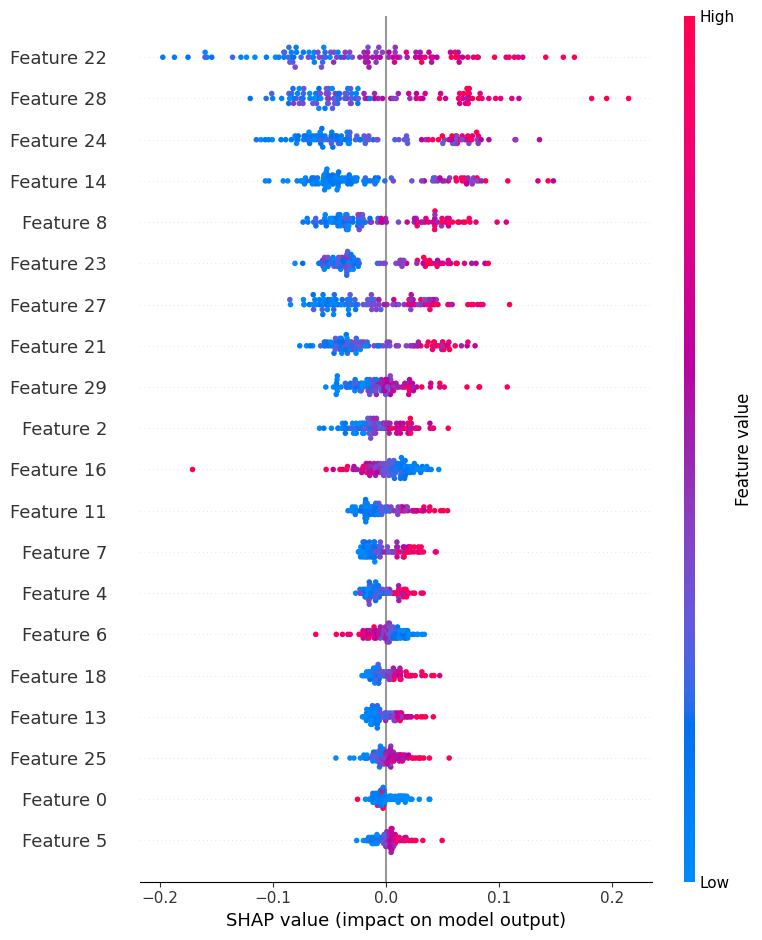

In [ ]:
import shap
import numpy as np

def f_stack(X):
    return stack.predict_proba(X)[:, 1]

explainer = shap.Explainer(f_stack, X_train_bal[:1000])
shap_values = explainer(X_test_scaled[:200])

shap.summary_plot(shap_values)

/tmp/ipykernel_11789/1514023641.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(model_scores.keys()), y=list(model_scores.values()), palette="viridis")


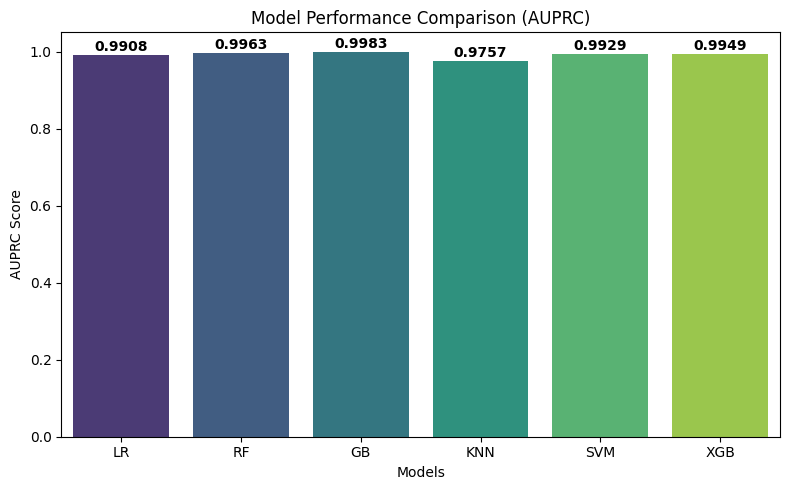

/tmp/ipykernel_11789/1514023641.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], x=list(stability_scores.keys()), y=list(stability_scores.values()), palette="magma")
/tmp/ipykernel_11789/1514023641.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], x=list(final_scores.keys()), y=list(final_scores.values()), palette="coolwarm")


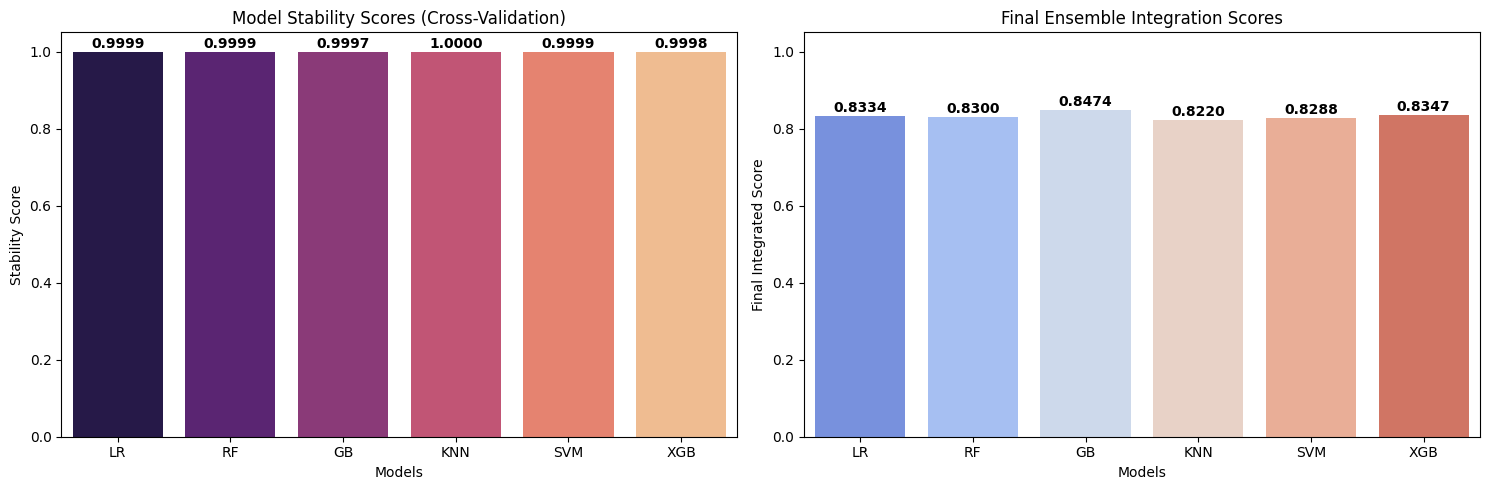

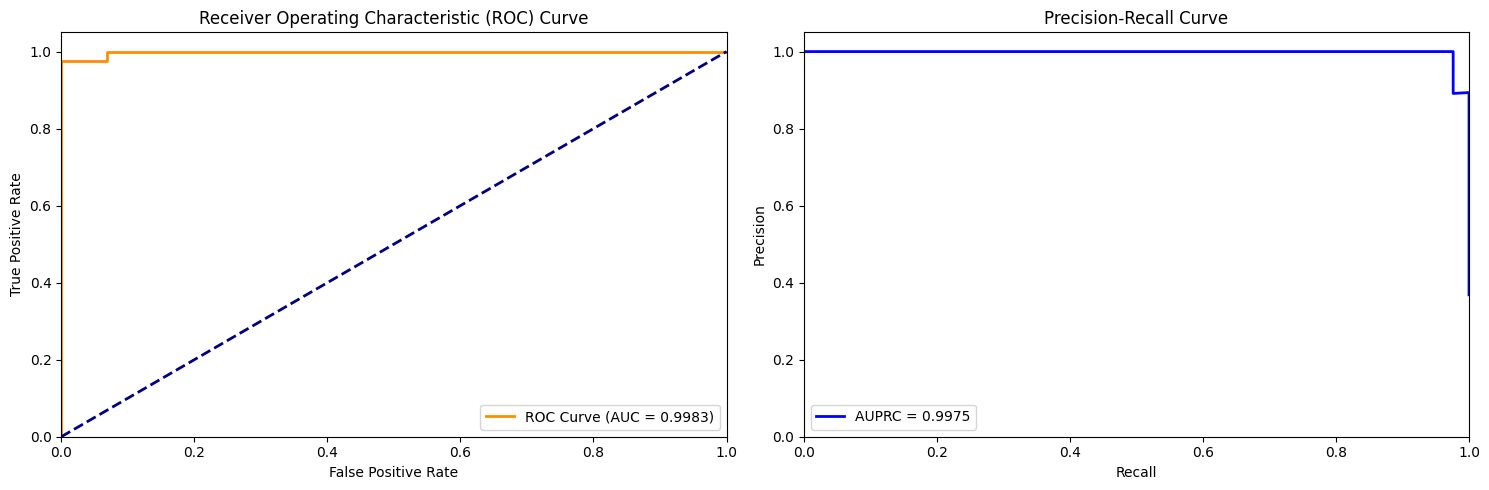

/tmp/ipykernel_11789/1514023641.py:83: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_scaled[:200], feature_names=X.columns)


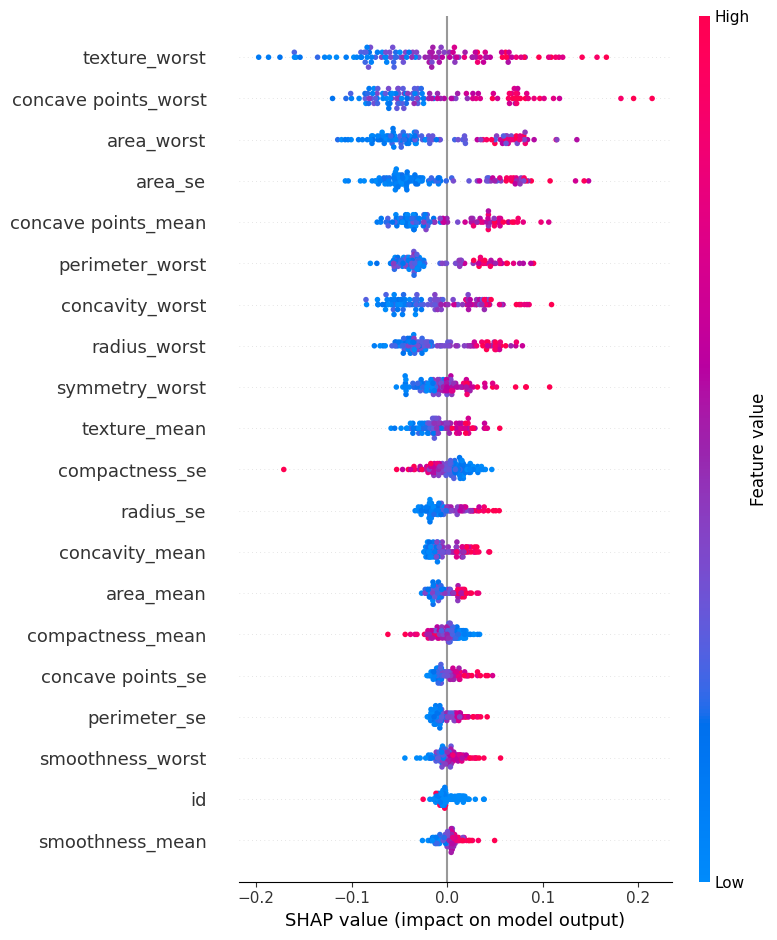

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
import shap

# ==========================================
# 1. Individual Model Performance (AUPRC)
# ==========================================
plt.figure(figsize=(8, 5))
sns.barplot(x=list(model_scores.keys()), y=list(model_scores.values()), palette="viridis")
plt.title("Model Performance Comparison (AUPRC)")
plt.xlabel("Models")
plt.ylabel("AUPRC Score")
plt.ylim(0, 1.05)
for i, v in enumerate(model_scores.values()):
    plt.text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# ==========================================
# 2. Stability and Final Selection Scores
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stability Scores Plot
sns.barplot(ax=axes[0], x=list(stability_scores.keys()), y=list(stability_scores.values()), palette="magma")
axes[0].set_title("Model Stability Scores (Cross-Validation)")
axes[0].set_xlabel("Models")
axes[0].set_ylabel("Stability Score")
axes[0].set_ylim(0, 1.05)
for i, v in enumerate(stability_scores.values()):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

# Final Integrated Scores Plot
sns.barplot(ax=axes[1], x=list(final_scores.keys()), y=list(final_scores.values()), palette="coolwarm")
axes[1].set_title("Final Ensemble Integration Scores")
axes[1].set_xlabel("Models")
axes[1].set_ylabel("Final Integrated Score")
axes[1].set_ylim(0, 1.05)
for i, v in enumerate(final_scores.values()):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# ==========================================
# 3. Stacked Model Evaluation Curves
# ==========================================
# Generate predictions for ROC and Precision-Recall
stack_probs = stack.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, stack_probs)
roc_auc = auc(fpr, tpr)
precision, recall, _ = precision_recall_curve(y_test, stack_probs)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ROC Curve
axes[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[0].legend(loc="lower right")

# Precision-Recall Curve
axes[1].plot(recall, precision, color='blue', lw=2, label=f'AUPRC = {auprc:.4f}')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

# ==========================================
# 4. SHAP (Shape) Summary Plot
# ==========================================
# Generates the feature importance summary plot with original column names
shap.summary_plot(shap_values, X_test_scaled[:200], feature_names=X.columns)